# ClimateGuard AI v3.0 - Anomaly Detection

This notebook covers detecting weather anomalies using various algorithms.

## 1. Import Libraries

In [1]:
## 2. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add src to path
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '..')))

from src.models.anomaly_detection import ClimateAnomalyDetector

# Ensure plots are displayed inline
%matplotlib inline

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Climate Risk Scores Data

In [2]:
# Load data from climate risk score step
df = pd.read_csv('../data/processed/09_climate_risk_scores.csv')
print(f"Data loaded: {df.shape}")
print(f"Columns: {len(df.columns)}")

Data loaded: (119398, 78)
Columns: 78


## 3. Prepare Features for Anomaly Detection

In [3]:
# Select numerical features for anomaly detection
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove non-feature columns
feature_cols = [col for col in numerical_cols if 'climate_zone' not in col and 'overall_score' not in col and 'category' not in col and 'color' not in col and 'weights_used' not in col]

X = df[feature_cols].fillna(0)

print(f"Features for anomaly detection: {len(X.columns)}")
print(f"Samples: {len(X)}")

Features for anomaly detection: 49
Samples: 119398


## 4. Initialize Anomaly Detector

In [4]:
detector = ClimateAnomalyDetector(X)
print("Anomaly detector initialized")

Anomaly detector initialized


## 5. Isolation Forest Detection

In [5]:
print("Running Isolation Forest...")
iso_labels, iso_scores = detector.isolation_forest_detection(contamination=0.1)
print(f"Anomalies detected: {(iso_labels == -1).sum()}")
print(f"Anomaly percentage: {(iso_labels == -1).sum() / len(iso_labels) * 100:.2f}%")

Running Isolation Forest...


INFO:src.models.anomaly_detection:Data preprocessed and scaled
INFO:src.models.anomaly_detection:Isolation Forest detected 11940 anomalies


Anomalies detected: 11940
Anomaly percentage: 10.00%


## 6. One-Class SVM Detection

In [6]:
print("Running One-Class SVM...")
svm_labels, svm_scores = detector.one_class_svm_detection(nu=0.1)
print(f"Anomalies detected: {(svm_labels == -1).sum()}")
print(f"Anomaly percentage: {(svm_labels == -1).sum() / len(svm_labels) * 100:.2f}%")

Running One-Class SVM...


INFO:src.models.anomaly_detection:One-Class SVM detected 11943 anomalies


Anomalies detected: 11943
Anomaly percentage: 10.00%


## 7. Local Outlier Factor Detection

In [7]:
print("Running Local Outlier Factor...")
lof_labels = detector.local_outlier_factor_detection(n_neighbors=20, contamination=0.1)
print(f"Anomalies detected: {(lof_labels == -1).sum()}")
print(f"Anomaly percentage: {(lof_labels == -1).sum() / len(lof_labels) * 100:.2f}%")

Running Local Outlier Factor...


INFO:src.models.anomaly_detection:LOF detected 11940 anomalies


Anomalies detected: 11940
Anomaly percentage: 10.00%


## 8. Elliptic Envelope Detection

In [8]:
print("Running Elliptic Envelope...")
ee_labels, ee_scores = detector.elliptic_envelope_detection(contamination=0.1)
print(f"Anomalies detected: {(ee_labels == -1).sum()}")
print(f"Anomaly percentage: {(ee_labels == -1).sum() / len(ee_labels) * 100:.2f}%")

Running Elliptic Envelope...


INFO:src.models.anomaly_detection:Elliptic Envelope detected 11940 anomalies


Anomalies detected: 11940
Anomaly percentage: 10.00%


## 9. Ensemble Anomaly Detection

In [9]:
import pickle
import os

# Save the Anomaly Detector with trained models
model_dir = '../models'
os.makedirs(model_dir, exist_ok=True)

# Save the detector object which contains all trained models
with open(f'{model_dir}/10_anomaly_detector.pkl', 'wb') as f:
    pickle.dump(detector, f)

print(f"Anomaly Detector saved to {model_dir}/10_anomaly_detector.pkl")

# Also save the scaler if it exists
if hasattr(detector, 'scaler') and detector.scaler is not None:
    with open(f'{model_dir}/10_anomaly_scaler.pkl', 'wb') as f:
        pickle.dump(detector.scaler, f)
    print(f"Scaler saved to {model_dir}/10_anomaly_scaler.pkl")

Anomaly Detector saved to ../models/10_anomaly_detector.pkl
Scaler saved to ../models/10_anomaly_scaler.pkl


In [10]:
print("Running Ensemble Detection...")
ensemble_labels = detector.ensemble_detection(
    methods=['isolation_forest', 'one_class_svm', 'elliptic_envelope'],
    voting='majority'
)
print(f"Anomalies detected: {(ensemble_labels == -1).sum()}")
print(f"Anomaly percentage: {(ensemble_labels == -1).sum() / len(ensemble_labels) * 100:.2f}%")

Running Ensemble Detection...


INFO:src.models.anomaly_detection:Isolation Forest detected 11940 anomalies
INFO:src.models.anomaly_detection:One-Class SVM detected 11943 anomalies
INFO:src.models.anomaly_detection:Elliptic Envelope detected 11940 anomalies
INFO:src.models.anomaly_detection:Ensemble detected 9765 anomalies


Anomalies detected: 9765
Anomaly percentage: 8.18%


## 10. Get Anomaly Details

In [11]:
# Use ensemble labels as final
detector.anomaly_labels = ensemble_labels
anomaly_details = detector.get_anomaly_details()

print(f"Anomaly details shape: {anomaly_details.shape}")
print(f"\nAnomaly distribution:")
print(anomaly_details['is_anomaly'].value_counts())

Anomaly details shape: (119398, 51)

Anomaly distribution:
is_anomaly
0    109633
1      9765
Name: count, dtype: int64


## 11. Visualize Anomaly Scores

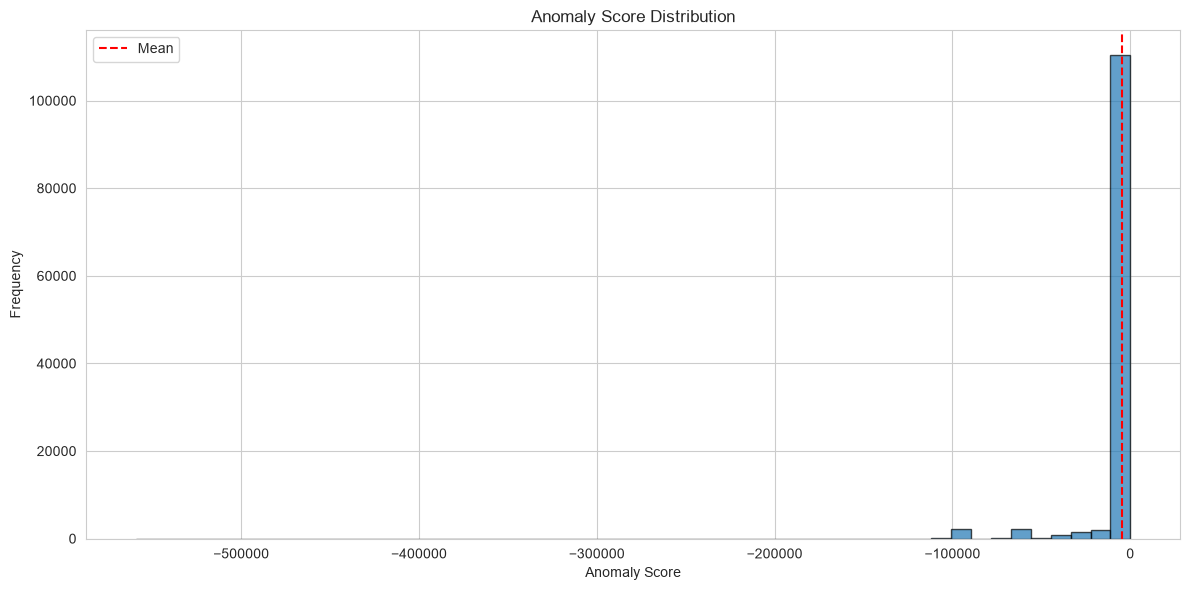

Anomaly score distribution plot displayed


In [12]:
if 'anomaly_score' in anomaly_details.columns:
    plt.figure(figsize=(12, 6))
    plt.hist(anomaly_details['anomaly_score'], bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel('Anomaly Score')
    plt.ylabel('Frequency')
    plt.title('Anomaly Score Distribution')
    plt.axvline(anomaly_details['anomaly_score'].mean(), color='red', linestyle='--', label='Mean')
    plt.legend()
    plt.tight_layout()
    plt.show()
    print("Anomaly score distribution plot displayed")

## 12. Anomalies by Climate Zone

In [13]:
if 'climate_zone' in anomaly_details.columns:
    zone_anomalies = anomaly_details.groupby('climate_zone')['is_anomaly'].agg(['sum', 'count'])
    zone_anomalies['percentage'] = (zone_anomalies['sum'] / zone_anomalies['count'] * 100).round(2)
    
    plt.figure(figsize=(12, 6))
    zone_anomalies['percentage'].plot(kind='bar')
    plt.xlabel('Climate Zone')
    plt.ylabel('Anomaly Percentage')
    plt.title('Anomaly Percentage by Climate Zone')
    plt.tight_layout()
    plt.show()
    print("Anomaly by climate zone plot displayed")

In [14]:
print(anomaly_details.columns.tolist())
print('climate_zone' in anomaly_details.columns)

['latitude', 'longitude', 'temperature', 'wind_mph', 'wind_degree', 'pressure', 'precipitation', 'humidity', 'cloud_cover', 'visibility', 'uv_index', 'gust_mph', 'carbon_monoxide', 'ozone', 'nitrogen_dioxide', 'sulphur_dioxide', 'pm2_5', 'pm10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'moon_illumination', 'year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend', 'is_monsoon', 'temp_rolling_7d', 'temp_trend', 'feels_like_diff', 'rain_flag', 'rain_rolling_7d', 'cumulative_rainfall', 'gust_difference', 'wind_severity', 'comfort_index', 'dew_point', 'fog_indicator', 'low_visibility_alert', 'pm_ratio', 'air_quality_alert', 'temperature_risk', 'humidity_risk', 'rainfall_risk', 'air_quality_risk', 'uv_index_risk', 'wind_speed_risk', 'pressure_risk', 'is_anomaly', 'anomaly_score']
False


## 13. Analyze Anomalous Records

In [15]:
anomalies = anomaly_details[anomaly_details['is_anomaly'] == 1]
print(f"Total anomalies: {len(anomalies)}")

if len(anomalies) > 0:
    print("\nAverage values in anomalous records:")
    for col in feature_cols[:5]:
        if col in anomalies.columns:
            print(f"  {col}: {anomalies[col].mean():.2f}")

Total anomalies: 9765

Average values in anomalous records:
  latitude: 23.90
  longitude: 81.72
  temperature: 19.91
  wind_mph: 5.59
  wind_degree: 160.46


## 14. Print Anomaly Detection Report

In [16]:
detector.print_report()

CLIMATE ANOMALY DETECTION REPORT

ISOLATION_FOREST:
  Number of anomalies: 11940
  Anomaly percentage: 10.00%
  Contamination parameter: 0.1

ONE_CLASS_SVM:
  Number of anomalies: 11943
  Anomaly percentage: 10.00%
  Nu parameter: 0.1

LOCAL_OUTLIER_FACTOR:
  Number of anomalies: 11940
  Anomaly percentage: 10.00%
  Contamination parameter: 0.1

ELLIPTIC_ENVELOPE:
  Number of anomalies: 11940
  Anomaly percentage: 10.00%
  Contamination parameter: 0.1

ENSEMBLE:
  Number of anomalies: 9765
  Anomaly percentage: 8.18%



## 15. Add Anomaly Labels to Dataset

In [17]:
# Add ensemble labels to original data
df['is_anomaly'] = ensemble_labels
df['anomaly_score'] = detector.anomaly_scores if detector.anomaly_scores is not None else 0

print(f"Added anomaly labels to dataset")
print(f"Anomaly distribution:")
print(df['is_anomaly'].value_counts())

Added anomaly labels to dataset
Anomaly distribution:
is_anomaly
 1    109633
-1      9765
Name: count, dtype: int64


## 16. Save Data with Anomaly Labels

In [18]:
df.to_csv('../data/processed/10_anomaly_detection.csv', index=False)
print("\nData with anomaly labels saved to ../data/processed/10_anomaly_detection.csv")


Data with anomaly labels saved to ../data/processed/10_anomaly_detection.csv


## Summary

In this notebook, we:
1. Loaded the climate risk scores data
2. Prepared features for anomaly detection
3. Applied Isolation Forest for anomaly detection
4. Applied One-Class SVM for anomaly detection
5. Applied Local Outlier Factor for anomaly detection
6. Applied Elliptic Envelope for anomaly detection
7. Applied ensemble anomaly detection
8. Analyzed anomaly details and distribution 
9. Visualized anomaly scores
10. Analyzed anomalies by climate zone
11. Examined anomalous records
12. Added anomaly labels to dataset
13. Saved data with anomaly labels for explainable AI

Next: Explainable AI (SHAP)